In [1]:
# Import necessary libraries for visualization, modeling, and balancing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

In [ ]:
# 1. Load the dataset using your specific local directory path
file_path = r"H:\My Drive\NeuroFive Solutions Internship\Week 5\dataset\creditcard.zip"
df = pd.read_csv(file_path)
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64

Fraudulent cases percentage: 0.173%


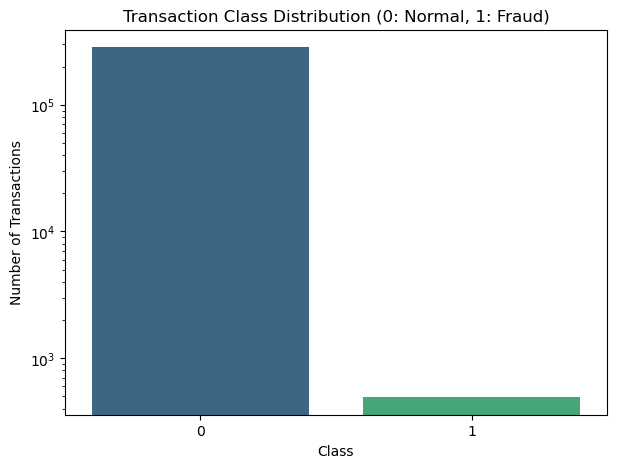

In [3]:
# 2. Check the distribution of the target variable 'Class'
class_counts = df['Class'].value_counts()
print("Class Distribution:\n", class_counts)

# Calculate and print the percentage of fraudulent transactions
fraud_percentage = (class_counts[1] / len(df)) * 100
print(f"\nFraudulent cases percentage: {fraud_percentage:.3f}%")

# Visualize the class balance using a bar chart
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Class', hue='Class', palette='viridis', legend=False)
plt.title('Transaction Class Distribution (0: Normal, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.yscale('log') # Using log scale because the difference is massive
plt.show()

In [4]:
# Separate features (X) and target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (227845, 30)
Testing features shape: (56962, 30)


In [5]:
# Train a baseline Logistic Regression model on the imbalanced data
baseline_model = LogisticRegression(max_iter=3000)
baseline_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_baseline = baseline_model.predict(X_test)

# Evaluate the baseline model focusing on Precision, Recall, and F1
print("--- Baseline Model Evaluation (Before Balancing) ---")
print(classification_report(y_test, y_pred_baseline))

--- Baseline Model Evaluation (Before Balancing) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.90      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
# 3. Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print("Class distribution after SMOTE (Training Set):")
print(y_train_balanced.value_counts())

Class distribution after SMOTE (Training Set):
Class
0    227451
1    227451
Name: count, dtype: int64


In [7]:
# 4. Retrain the model using the balanced training data
balanced_model = LogisticRegression(max_iter=1000)
balanced_model.fit(X_train_balanced, y_train_balanced)

# Predict on the ORIGINAL UNBALANCED test set
y_pred_balanced = balanced_model.predict(X_test)

# Evaluate the balanced model
print("--- Balanced Model Evaluation (After SMOTE) ---")
print(classification_report(y_test, y_pred_balanced))

--- Balanced Model Evaluation (After SMOTE) ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56864
           1       0.13      0.90      0.23        98

    accuracy                           0.99     56962
   macro avg       0.57      0.94      0.61     56962
weighted avg       1.00      0.99      0.99     56962



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#### Why "Accuracy" is a Misleading Metric Here?

In highly imbalanced datasets like Credit Card Fraud Detection, normal transactions usually make up over 99.8% of the data. If a "dumb" model simply predicts that every single transaction is normal (Class 0), it will still achieve an accuracy of 99.8%.

While the accuracy metric looks fantastic, the model would have completely failed at its actual purpose: identifying fraud. It would have a Recall of 0 for fraudulent cases. Therefore, in such scenarios, "Accuracy" creates a false sense of success (the Accuracy Paradox). Instead, we must rely on metrics like Recall (how many actual frauds did we catch?) and F1-Score (the balance between Precision and Recall) to truly evaluate the model's usefulness.